# Laboratory Day 5b: Houph transformation


**Exercise 2.1 (30 points)**
Implement Hough Transformation by yourself and apply it to image "airplane.png" to detect the white lines on the aircraft runway.

HT consists of the following 3 steps:

(1) Edge detection. It is recommended to call Canny edge detector, cv2.Canny(). After step (1), please display the image of all detected edge points. (5 points)

(2) Transformation the detected edge points into their parameter space. Please implement a function for this step, e.g. hough_transformation_line(image, delta_r, delta_phi) -> accumulator matrix. delta_r and delta_phi are small distances for discretization of parameter space. After step (2), please display the accumulator matrix, when it is applied to the edge image of "airplance.png". (15 points)


(3) Find out the local maxima in the accumulator matrix manually. These local maxima refer to the detected lines. Please display the represented lines of these maxima in an image (for each detected $r$ and $\phi$, convert it back to a line). To check your results, the position of these lines should be roughly the same as the white lines on the aircraft runway. (10 points)




Edge Detection Setup and Canny Application: First, let's load the airplane.png image. Remember that cv2.Canny() typically works best on grayscale images, so you might need to convert your image first. Consider what parameters (threshold1, threshold2, apertureSize) for cv2.Canny() are most appropriate for this image to effectively highlight the white lines on the runway. What are these parameters controlling, and how might they influence the detected edges? After applying Canny, display the resulting binary edge image. What does a good edge image look like for this task, and how can you assess if your Canny parameters are well-tuned?
Hough Transform Parameter Space Discretization: Now, let's prepare for the Hough Transformation. Your hough_transformation_line function needs to define the parameter space for rho and phi. How will you discretize phi within the range [0, pi] using delta_phi? How will you determine the maximum possible rho (r_max) for your image size, and then discretize rho within [-r_max, r_max] using delta_r? What are the implications of choosing small versus large delta_r and delta_phi values on the accuracy and computational cost?
Implement Accumulator Matrix: Proceed with implementing the core of the hough_transformation_line function. Initialize an accumulator matrix with dimensions corresponding to your discretized rho_s and phi_s. For each non-zero (edge) pixel in your Canny output, how will you iterate through all possible phi values and calculate the corresponding rho? How will you then increment the correct bin in your accumulator matrix? Consider using np.sin() and np.cos() for the trigonometric calculations. What happens if a calculated rho falls outside your defined rho_s range?
Visualize Accumulator Matrix: After computing the accumulator matrix, it's crucial to visualize it to understand the results. How can you normalize the accumulator matrix values so that the local maxima are clearly visible when displayed as an image (e.g., using matplotlib.pyplot.imshow())? Why is normalization important here? What do bright spots in this matrix represent?
Find Local Maxima and Convert to Lines: The next step is to identify the most prominent lines by finding local maxima in your accumulator matrix. How can you manually (or programmatically) find these 'bright spots'? Once you have the (rho_index, phi_index) for a local maximum, how do you convert these indices back into the actual rho and phi values that define a line in the image space (x cos(phi) + y sin(phi) = rho)? What criteria will you use to select 'significant' local maxima?
Display Detected Lines: Finally, draw these detected lines back onto your original 'airplane.png' image (or a copy of it). How can you draw a line given its rho and phi parameters using OpenCV's drawing functions (e.g., cv2.line())? Ensure the lines extend across the image. After drawing, visually inspect the result: do the lines correspond accurately to the white lines on the aircraft runway? If not, what parameters (Canny, delta_r, delta_phi, or maxima threshold) might you need to adjust?
Final Task: Review the complete implementation of the Hough Transformation. Evaluate how well the detected lines match the runway lines in 'airplane.png'. Summarize the challenges you encountered and how you addressed them, and reflect on the impact of different parameter choices.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

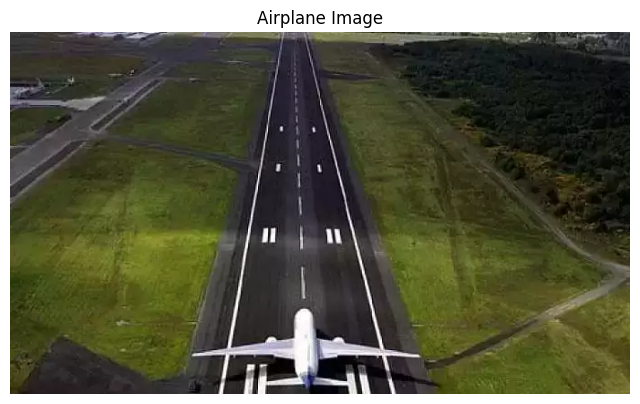

In [17]:
image =  cv2.imread("/airplane.png")

# Convert the image from BGR to RGB format for correct display with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title('Airplane Image')
plt.axis('off')
plt.show()

In [11]:
# Edge detection using Canny
def edge_detection(imagepath, threshold1, threshold2, apertureSize):
  image = cv2.imread(imagepath)
  if image is None:
      raise FileNotFoundError(f"Image not found at {imagepath} or could not be loaded.")
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  edges = cv2.Canny(gray, threshold1, threshold2, apertureSize=apertureSize)
  return image, edges

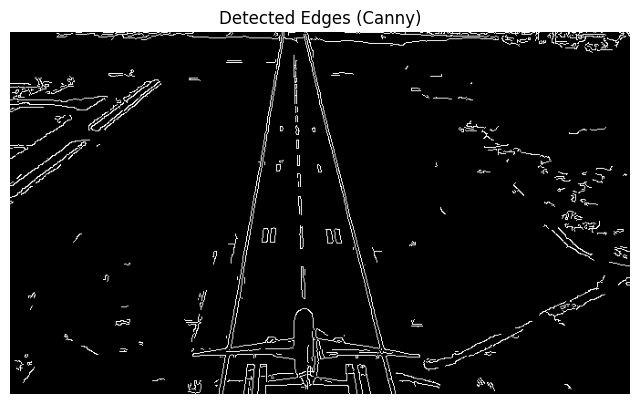

In [6]:
# Perform Canny edge detection and display the edge image
original_image, edges = edge_detection("/airplane.png", 100, 200, 3)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.title('Detected Edges (Canny)')
plt.axis('off')
plt.show()

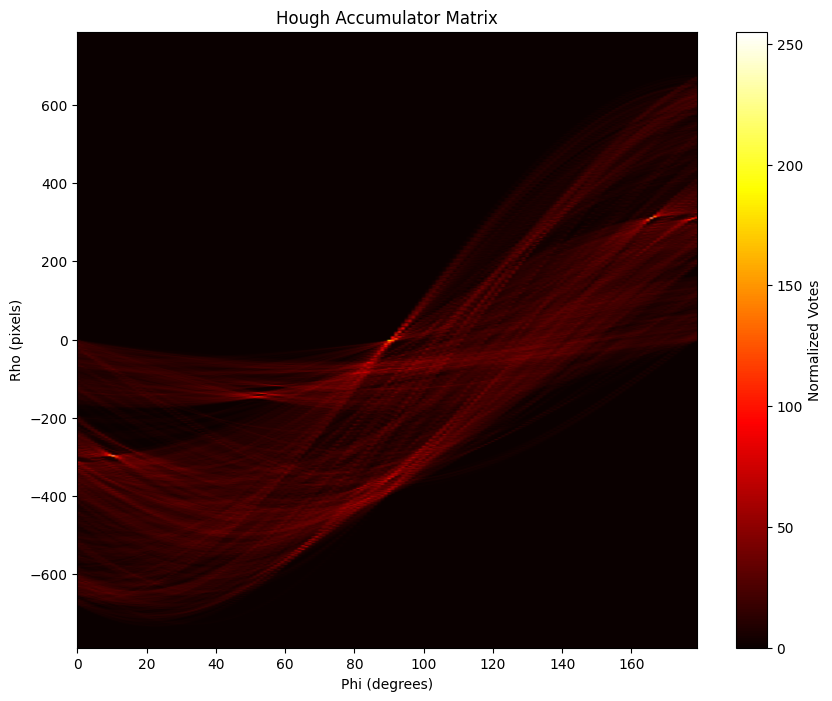

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# HT implementation: Transforms edge points to parameter space and builds accumulator.
def hough_transformation_line(image, delta_r, delta_phi):
    # Discretize rho and phi parameter space.
    phi_s = np.arange(0, np.pi, delta_phi)
    height, width = image.shape
    r_max = np.sqrt(height**2 + width**2)
    rho_s = np.arange(-r_max, r_max, delta_r)

    # Accumulator: stores votes for potential lines.
    accumulator = np.zeros((len(rho_s), len(phi_s)), dtype=np.uint64)
    y_coords, x_coords = np.argwhere(image == 255).T

    for x, y in zip(x_coords, y_coords):
      for phi_index, phi in enumerate(phi_s):
        rho = x * np.cos(phi) + y * np.sin(phi)
        rho_index = np.argmin(np.abs(rho_s - rho))
        accumulator[rho_index, phi_index] += 1

    return accumulator, rho_s, phi_s

delta_r = 1
delta_phi = np.pi / 180

if 'edges' not in locals() or edges is None:
    print("Error: 'edges' image not found or empty. Please ensure Canny edge detection runs successfully.")
else:
    accumulator, rho_s, phi_s = hough_transformation_line(edges, delta_r, delta_phi)
    if accumulator.max() > 0:
        accumulator_normalized = accumulator / accumulator.max() * 255
    else:
        accumulator_normalized = np.zeros_like(accumulator)

    plt.figure(figsize=(10, 8))
    plt.imshow(accumulator_normalized, cmap='hot',
               extent=[np.degrees(phi_s.min()), np.degrees(phi_s.max()), rho_s.min(), rho_s.max()],
               aspect='auto')
    plt.title('Hough Accumulator Matrix')
    plt.xlabel('Phi (degrees)')
    plt.ylabel('Rho (pixels)')
    plt.colorbar(label='Normalized Votes')
    plt.show()

Found 9 potential line candidates above the threshold.


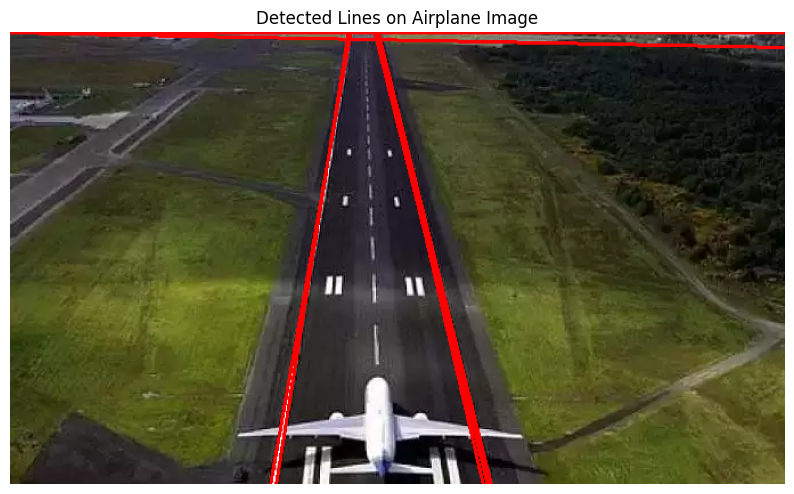

In [21]:
# draw_line: helper to plot lines given rho and phi.
def draw_line(image, rho, phi, color=(0, 0, 255), thickness=2):
    a = np.cos(phi)
    b = np.sin(phi)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image, (x1, y1), (x2, y2), color, thickness)

# Find local maxima in accumulator and draw lines on image.
threshold_votes = accumulator.max() * 0.6
line_candidates_indices = np.argwhere(accumulator > threshold_votes)
image_with_lines = original_image.copy()

print(f"Found {len(line_candidates_indices)} potential line candidates above the threshold.")

for rho_idx, phi_idx in line_candidates_indices:
    rho = rho_s[rho_idx]
    phi = phi_s[phi_idx]
    draw_line(image_with_lines, rho, phi)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image_with_lines, cv2.COLOR_BGR2RGB))
plt.title('Detected Lines on Airplane Image')
plt.axis('off')
plt.show()